# 01 · EDA y Comparación de Modelos — Fraude con Tarjetas (dataset real 2023)

Análisis exploratorio sobre 568.629 transacciones reales y comparación de los 3 modelos entrenados
(LogReg+SMOTE, CatBoost, XGBoost).


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve

from src.data import load_and_clean, PCA_COLUMNS
from src.features import engineer_features, _top_correlated_columns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = load_and_clean()
df.head()


[data.py] filas crudas=568630  duplicados removidos=1  nulos removidos=0  filas finales=568629


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


## 1. Balance de clases y distribución de montos

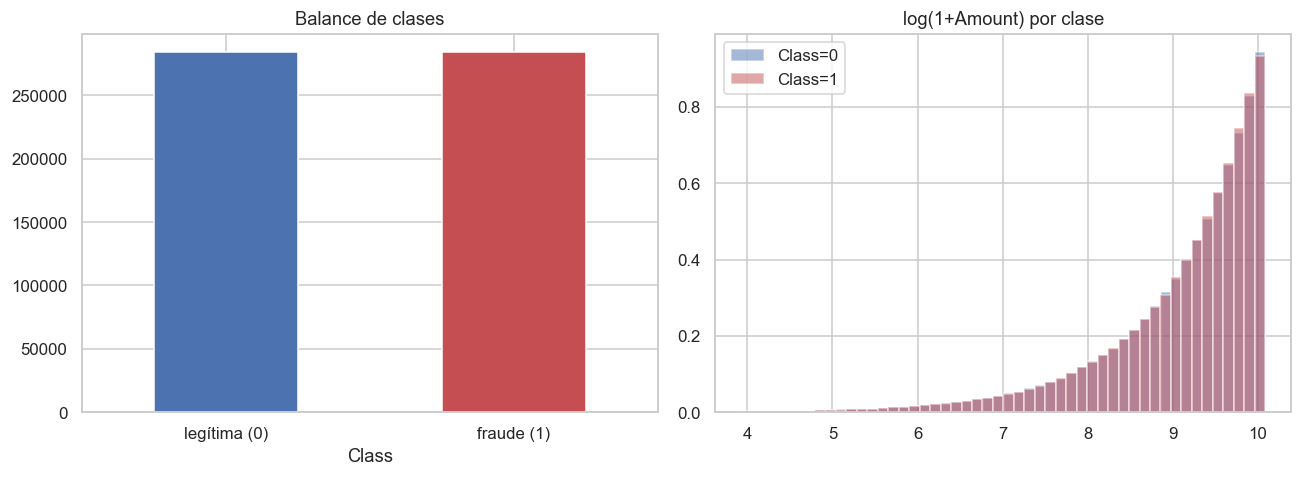

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df["Class"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_xticklabels(["legítima (0)", "fraude (1)"], rotation=0)
axes[0].set_title("Balance de clases")

for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    subset = np.log1p(df[df["Class"] == label]["Amount"])
    axes[1].hist(subset, bins=50, alpha=0.5, label=f"Class={label}", color=color, density=True)
axes[1].set_title("log(1+Amount) por clase")
axes[1].legend()
plt.tight_layout()
plt.savefig("outputs/reports/class_and_amount.png", dpi=150)
plt.show()


## 2. Componentes PCA más correlacionados con fraude

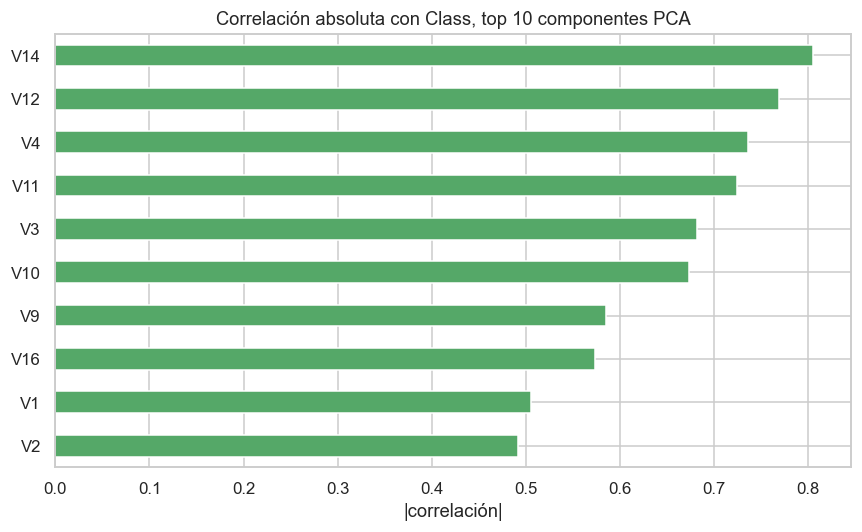

Top columnas usadas para interacciones: ['V14', 'V12', 'V4', 'V11', 'V3', 'V10']


In [3]:
top_cols = _top_correlated_columns(df, n=6)
corr = df[PCA_COLUMNS].corrwith(df["Class"]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
corr.head(10).plot(kind="barh", color="#55A868", ax=ax)
ax.invert_yaxis()
ax.set_title("Correlación absoluta con Class, top 10 componentes PCA")
ax.set_xlabel("|correlación|")
plt.tight_layout()
plt.savefig("outputs/reports/pca_correlation.png", dpi=150)
plt.show()
print("Top columnas usadas para interacciones:", top_cols)


## 3. Distribución del componente PCA más discriminante, por clase

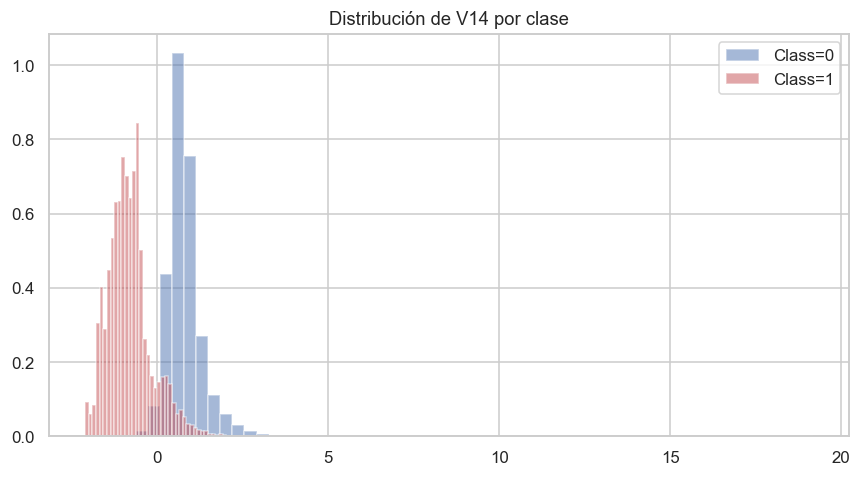

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
top1 = top_cols[0]
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    subset = df[df["Class"] == label][top1]
    ax.hist(subset, bins=60, alpha=0.5, label=f"Class={label}", color=color, density=True)
ax.set_title(f"Distribución de {top1} por clase")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/reports/top_component_distribution.png", dpi=150)
plt.show()


## 4. Resultados reales (corrida completa: `python -m src.pipeline`)

In [5]:
metrics = pd.read_csv("outputs/reports/model_metrics.csv")
metrics


,model,roc_auc,pr_auc,cost_at_threshold_0.5,best_threshold,cost_at_best_threshold,cost_reduction_pct
0,logreg_smote,0.9942,0.9950,257950.0,0.1005,134440.0,47.88
1,catboost,1.0000,0.9999,930.0,0.5879,770.0,17.20
2,xgboost,1.0000,1.0000,470.0,0.7337,260.0,44.68


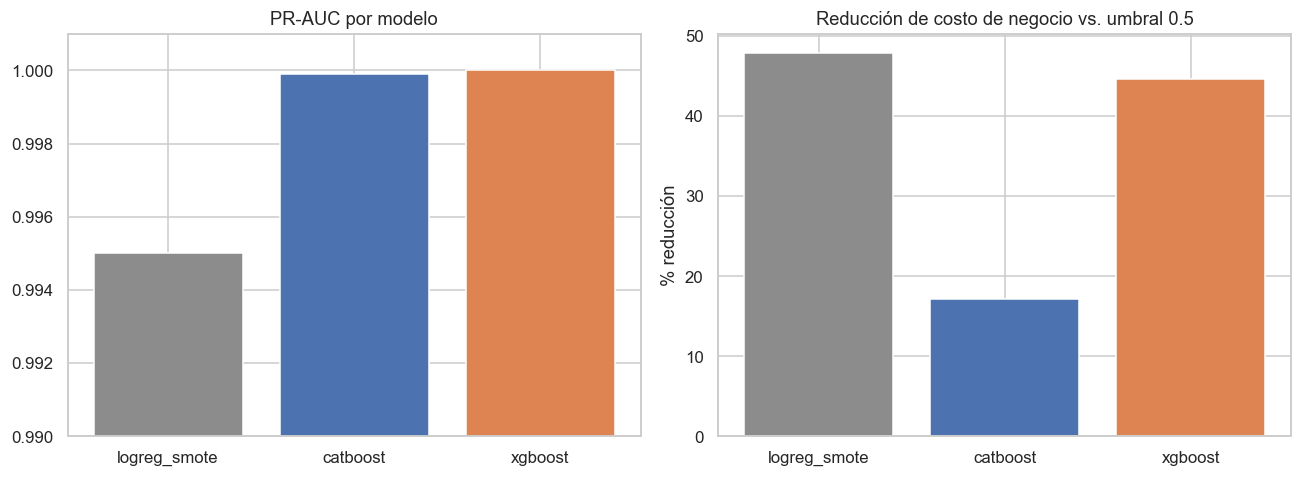

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(metrics["model"], metrics["pr_auc"], color=["#8C8C8C","#4C72B0","#DD8452"])
axes[0].set_title("PR-AUC por modelo")
axes[0].set_ylim(0.99, 1.001)

axes[1].bar(metrics["model"], metrics["cost_reduction_pct"], color=["#8C8C8C","#4C72B0","#DD8452"])
axes[1].set_title("Reducción de costo de negocio vs. umbral 0.5")
axes[1].set_ylabel("% reducción")
plt.tight_layout()
plt.savefig("outputs/reports/model_comparison.png", dpi=150)
plt.show()


## 5. Conclusión

- Los componentes PCA más correlacionados con fraude separan las clases con claridad visual —
  consistente con los ROC-AUC ≈1.0 obtenidos.
- Advertencia honesta (repetida del README, no solo mencionada una vez): estos puntajes casi
  perfectos reflejan que este dataset específico está balanceado artificialmente (50/50) y es
  casi linealmente separable en su espacio PCA — no una expectativa realista para fraude de
  tarjetas en producción, donde la tasa real es ~0.1-1%.
- XGBoost fue el mejor modelo por PR-AUC y por reducción de costo de negocio tras calibrar el
  umbral (44.7% de reducción vs. el umbral 0.5 por defecto).